In [3]:
%load_ext autoreload
%autoreload 2

# --- Standard library ---
from pathlib import Path

# --- Third-party ---
import os
from joblib import Parallel, delayed, parallel_backend
import time
import numpy as np
import pandas as pd
from pandas.api.types import is_integer_dtype
from sklearn.metrics import roc_auc_score, mean_squared_error, accuracy_score
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display, HTML

# --- Local / application ---
from rf_plateau_hpo.datasets.dataloader import load_dataset, load_datasets_yaml

# !pip install -qq "dill>=0.4.0" "typing_extensions>=3.10" "matplotlib>=3.5" "seaborn>=0.11.2" "pandas>=2.0.3" "numpy==1.24.4"
from run_experiments import process_dataset
from analyze_experiments import (
    experiment_comparison_table, 
    process_html_table, 
    tab2tex, 
    plot_dataset_comparisons, 
    DEFAULT_DELTA_GRID,
    plot_delta_boxplots
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [4]:
ROOT = Path.cwd().parent
datasets_file = (ROOT / "data" / "datasets.yml").resolve()

yml = load_datasets_yaml(datasets_file)

for dataset in yml['datasets'].keys():
    X, y = load_dataset(dataset, yml=yml, base_dir=(ROOT / "data").resolve(), verbose=0)
    print(dataset, X.shape, 'reg' if not is_integer_dtype(y) else len(np.unique(y)))

iris (150, 4) 3
wine (178, 13) 3
breast_cancer (569, 30) 2
credit_card_default (30000, 23) 2
give_me_some_credit (150000, 10) 2
titanic (891, 8) 2
diabetes (442, 10) reg
abalone (4177, 8) 28
california_housing (20640, 8) reg
gene_expression_cancer_rna_seq (801, 20531) reg
arcene (200, 10000) 2
dorothea (1150, 100000) reg
gisette (7000, 5000) 2


# Experiments

## iris

In [ ]:
dataset="iris"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    X, y, "clf",
    score_func=lambda y, y_pred_prob: roc_auc_score(y, y_pred_prob, average='macro', multi_class='ovr'),
    greater_is_better=True,
    dataset='/tmp/a.lange/'+dataset,
    move_dir=dataset,
    verbose=1,
    random_state=0,
)

## wine

In [ ]:
dataset="wine"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    X, y, "clf",
    score_func=lambda y, y_pred_prob: roc_auc_score(
        y, y_pred_prob, average='macro', multi_class='ovr'
    ),
    greater_is_better=True,
    dataset='/tmp/a.lange/'+dataset,
    move_dir=dataset,
    verbose=1,
    random_state=0,
)

## breast_cancer

In [7]:
dataset="breast_cancer"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    X, y, "clf",
    score_func=lambda y, proba: roc_auc_score(y, proba[:, 1]),
    greater_is_better=True,
    dataset='/tmp/a.lange/'+dataset,
    move_dir=dataset,
    verbose=1,
    random_state=0,
    sort_params_by_random_state = True,
)

[clean] Source directory /tmp/a.lange/breast_cancer does not exist. Nothing to clean.
[FileMover] Started monitoring /tmp/a.lange/breast_cancer -> /beegfs/home/a.lange/RF_plateau_HPO/rf_plateau_hpo/notebooks/breast_cancer (min_age=10s, ignore_ext=.tmp, total_files=2140)


Moving files:   0%|          | 0/2140 [00:00<?, ?file/s]

[run_queue_pinned] tasks=900 | workers=80/80 | allowed_cpus=160 | sockets=[0, 1, 2, 3] | threads_per_core=2 | use_smt=True | socket_policy=prefer | static_keys=9 | inject_n_jobs=True | n_jobs_value=2 | override_n_jobs=True


Processing tasks:   0%|          | 0/900 [00:00<?, ?task/s]

[FileMover] All 2140 files moved
[FileMover] Stopped.


## credit_card_default

In [9]:
dataset="credit_card_default"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    X, y, "clf",
    score_func=lambda y, proba: roc_auc_score(y, proba[:, 1]),
    greater_is_better=True,
    dataset='/tmp/a.lange/'+dataset,
    move_dir=dataset,
    verbose=1,
    random_state=0,
    sort_params_by_random_state = True,
)

[clean] Source directory /tmp/a.lange/credit_card_default does not exist. Nothing to clean.
[FileMover] Started monitoring /tmp/a.lange/credit_card_default -> /beegfs/home/a.lange/RF_plateau_HPO/rf_plateau_hpo/notebooks/credit_card_default (min_age=10s, ignore_ext=.tmp, total_files=2140)


Moving files:   0%|          | 0/2140 [00:00<?, ?file/s]

[run_queue_pinned] tasks=900 | workers=80/80 | allowed_cpus=160 | sockets=[0, 1, 2, 3] | threads_per_core=2 | use_smt=True | socket_policy=prefer | static_keys=9 | inject_n_jobs=True | n_jobs_value=2 | override_n_jobs=True


Processing tasks:   0%|          | 0/900 [00:00<?, ?task/s]

[FileMover] All 2140 files moved
[FileMover] Stopped.


## give_me_some_credit

In [ ]:
dataset="give_me_some_credit"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

not_nan = X.notnull().all(axis=1)
X, y = X[not_nan], y[not_nan]
weights = compute_class_weight(class_weight="balanced", classes=np.unique(y), y=y)

process_dataset(
    X, y, "clf",
    score_func=lambda y_, proba: roc_auc_score(y_, proba[:, 1]),
    greater_is_better=True,
    dataset='/tmp/a.lange/'+dataset,
    move_dir=dataset,
    class_weight={0: weights[0], 1: weights[1]},
    verbose=1,
    random_state=0,
    sort_params_by_random_state = True,
)

[clean] Removed and recreated /tmp/a.lange/give_me_some_credit
[FileMover] Started monitoring /tmp/a.lange/give_me_some_credit -> /beegfs/home/a.lange/RF_plateau_HPO/rf_plateau_hpo/notebooks/give_me_some_credit (min_age=60s, ignore_ext=.tmp, total_files=2140)


Moving files:   0%|          | 0/2140 [00:00<?, ?file/s]

[run_queue_pinned] tasks=900 | workers=80/80 | allowed_cpus=160 | sockets=[0, 1, 2, 3] | threads_per_core=2 | use_smt=True | socket_policy=prefer | static_keys=10 | inject_n_jobs=True | n_jobs_value=2 | override_n_jobs=True


Processing tasks:   0%|          | 0/900 [00:00<?, ?task/s]

## titanic

In [ ]:
dataset="titanic"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

X['Sex'] = (X['Sex'] == 'male').astype(int)
X['EmbarkedC'] = (X['Embarked'] == 'C').astype(int)
X['EmbarkedQ'] = (X['Embarked'] == 'Q').astype(int)
X['EmbarkedS'] = (X['Embarked'] == 'S').astype(int)
X = X.drop(['Embarked'], axis=1)

def process_cabin(v):
    if pd.isna(v) or not isinstance(v, str) or not v.strip():
        return 0, 0
    
    first_cabin = v.strip().split()[0]
    if not first_cabin[0].isalpha():
        return 0, 0
    
    level = ord(first_cabin[0].upper()) - ord('A') + 1
    cabin_number_str = first_cabin[1:].strip()
    
    if cabin_number_str and cabin_number_str.isdigit():
        cabin_num = int(cabin_number_str)
    else:
        cabin_num = 0
    
    return level, cabin_num

X['Cabin_level'], X['Cabin_num'] = zip(*[process_cabin(v) for v in X['Cabin']])
X = X.drop(['Cabin'], axis=1)
X['Age'] = X['Age'].fillna(0)

process_dataset(
    X, y, "clf",
    score_func=lambda y, y_pred: accuracy_score(y, np.argmax(y_pred, axis=1)),
    greater_is_better=True,
    dataset='/tmp/a.lange/'+dataset,
    move_dir=dataset,
    delta_grid = (3e-3, 5e-3, 7e-3, 9e-3),
    max_trees=1000000,
    verbose=1,
    random_state=0
)

[clean] Source directory /tmp/a.lange/titanic does not exist. Nothing to clean.
[FileMover] Started monitoring /tmp/a.lange/titanic -> /beegfs/home/a.lange/RF_plateau_HPO/rf_plateau_hpo/notebooks/titanic (min_age=10s, ignore_ext=.tmp, total_files=1980)


Moving files:   0%|          | 0/1980 [00:00<?, ?file/s]

[run_queue_pinned] tasks=840 | workers=80/80 | allowed_cpus=160 | sockets=[0, 1, 2, 3] | threads_per_core=2 | use_smt=True | socket_policy=prefer | static_keys=9 | inject_n_jobs=True | n_jobs_value=2 | override_n_jobs=True


Processing tasks:   0%|          | 0/840 [00:00<?, ?task/s]

## diabetes

In [ ]:
dataset="diabetes"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    X, y, "reg",
    score_func=lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
    greater_is_better=False,
    dataset='/tmp/a.lange/'+dataset,
    move_dir=dataset,
    verbose=1,
    random_state=0,
    sort_params_by_random_state = True,
)

## abalone

In [10]:
dataset="abalone"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())
X['M, F, and I (infant)'].replace({'M': 2, 'F': 1, 'I': 0}, inplace=True)

process_dataset(
    X, y, "reg",
    score_func=lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
    greater_is_better=False,
    dataset='/tmp/a.lange/'+dataset,
    move_dir=dataset,
    verbose=1,
    random_state=0,
    sort_params_by_random_state = True,
)

[clean] Source directory /tmp/a.lange/abalone does not exist. Nothing to clean.
[FileMover] Started monitoring /tmp/a.lange/abalone -> /beegfs/home/a.lange/RF_plateau_HPO/rf_plateau_hpo/notebooks/abalone (min_age=10s, ignore_ext=.tmp, total_files=2140)


Moving files:   0%|          | 0/2140 [00:00<?, ?file/s]

[run_queue_pinned] tasks=900 | workers=80/80 | allowed_cpus=160 | sockets=[0, 1, 2, 3] | threads_per_core=2 | use_smt=True | socket_policy=prefer | static_keys=9 | inject_n_jobs=True | n_jobs_value=2 | override_n_jobs=True


Processing tasks:   0%|          | 0/900 [00:00<?, ?task/s]

[FileMover] All 2140 files moved
[FileMover] Stopped.


## california_housing

In [11]:
dataset="california_housing"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    X, y, "reg",
    score_func=lambda y, y_pred: np.sqrt(mean_squared_error(y, y_pred)),
    greater_is_better=False,
    tune_criterion_grid=[False],
    criterion='squared_error',
    dataset='/tmp/a.lange/'+dataset,
    move_dir=dataset,
    verbose=1,
    random_state=0,
    sort_params_by_random_state = True,
)

[clean] Source directory /tmp/a.lange/california_housing does not exist. Nothing to clean.
[FileMover] Started monitoring /tmp/a.lange/california_housing -> /beegfs/home/a.lange/RF_plateau_HPO/rf_plateau_hpo/notebooks/california_housing (min_age=10s, ignore_ext=.tmp, total_files=1820)


Moving files:   0%|          | 0/1820 [00:00<?, ?file/s]

[run_queue_pinned] tasks=740 | workers=80/80 | allowed_cpus=160 | sockets=[0, 1, 2, 3] | threads_per_core=2 | use_smt=True | socket_policy=prefer | static_keys=11 | inject_n_jobs=True | n_jobs_value=2 | override_n_jobs=True


Processing tasks:   0%|          | 0/740 [00:00<?, ?task/s]

[FileMover] All 1820 files moved
[FileMover] Stopped.


## gene_expression_cancer_rna_seq

In [ ]:
dataset="gene_expression_cancer_rna_seq"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

classes=np.unique(y)
weights = compute_class_weight(class_weight="balanced", classes=classes, y=y)

process_dataset(
    X, y, "clf",
    score_func=lambda y, y_pred: accuracy_score(y, classes[np.argmax(y_pred, axis=1)]),
    greater_is_better=True,
    delta_grid = (3e-3, 5e-3, 7e-3, 9e-3),
    class_weight={k: v for k, v in zip(classes, weights)},
    max_trees=1000000,
    dataset='/tmp/a.lange/'+dataset,
    move_dir=dataset,
    verbose=1,
    random_state=0,
    sort_params_by_random_state = True,
)

## arcene

In [ ]:
dataset="arcene"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

process_dataset(
    X, y, "clf",
    score_func=lambda y, proba: roc_auc_score(y, proba[:, 1]),
    greater_is_better=True,
    max_trees=1000000,
    dataset='/tmp/a.lange/'+dataset,
    move_dir=dataset,
    verbose=1,
    random_state=0,
    sort_params_by_random_state = True,
)

split done!
[clean] Removed and recreated /tmp/a.lange/arcene
[FileMover] Started monitoring /tmp/a.lange/arcene -> /beegfs/home/a.lange/RF_plateau_HPO/rf_plateau_hpo/notebooks/arcene (min_age=10s, ignore_ext=.tmp, total_files=2140)
file mover done!


Moving files:   0%|          | 0/2140 [00:00<?, ?file/s]

[run_queue_pinned] tasks=900 | workers=67/67 | allowed_cpus=134 | sockets=[0, 1, 2, 3] | threads_per_core=2 | use_smt=True | socket_policy=prefer | static_keys=9 | inject_n_jobs=True | n_jobs_value=2 | override_n_jobs=True


Processing tasks:   0%|          | 0/900 [00:00<?, ?task/s]

## dorothea

In [11]:
dataset="dorothea"
X, y = load_dataset(dataset, yml=datasets_file, base_dir=(ROOT / "data").resolve())

X = X.astype(pd.SparseDtype("uint8", 0))  # or "bool", but uint8 is ok
X = X.sparse.to_coo().tocsc().astype(np.float32)

process_dataset(
    X, y, "clf",
    score_func=lambda y, proba: roc_auc_score(y, proba[:, 1]),
    greater_is_better=True,
    method_grid= ['TPE'], 
    dataset='/tmp/a.lange/'+dataset,
    move_dir=dataset,
    max_trees=1000000,
    verbose=1,
    random_state=0,
    sort_params_by_random_state = True,
)

split done!
[clean] Source directory /tmp/a.lange/dorothea does not exist. Nothing to clean.
[FileMover] Started monitoring /tmp/a.lange/dorothea -> /beegfs/home/a.lange/RF_plateau_HPO/rf_plateau_hpo/notebooks/dorothea (min_age=10s, ignore_ext=.tmp, total_files=100)
file mover done!


Moving files:   0%|          | 0/100 [00:00<?, ?file/s]

[run_queue_pinned] tasks=40 | workers=13/13 | allowed_cpus=26 | sockets=[3] | threads_per_core=2 | use_smt=True | socket_policy=prefer | static_keys=13 | inject_n_jobs=True | n_jobs_value=2 | override_n_jobs=True


Processing tasks:   0%|          | 0/40 [00:00<?, ?task/s]

[FileMover] All 100 files moved
[FileMover] Stopped.


## gisette

# Table of results

In [7]:
dataset_folders = [
    './'+dataset for dataset in yml['datasets'].keys()
    if os.path.isdir('./'+dataset) and 'gisette' not in dataset 
]

dataset_folders = [
'./iris',
'./wine',
'./breast_cancer',
'./credit_card_default',
'./give_me_some_credit',
'./titanic',
'./diabetes',
'./abalone',
'./california_housing',
'./gene_expression_cancer_rna_seq',
'./arcene',
'./dorothea'
]

dfs = []
for dataset in dataset_folders:
    delta_min = DEFAULT_DELTA_GRID[1] if dataset in ['./titanic', './gene_expression_cancer_rna_seq'] else DEFAULT_DELTA_GRID[0]
    dfs.append(experiment_comparison_table(
        dataset,
        delta = (delta_min, DEFAULT_DELTA_GRID[-1]),
        save_plots=False, 
        show_epsilon_column = False, 
        show_effect_size = True
    ))
    print(f"{dataset} done!")

cols = []

# experimemnt settings columns
for k, v in dfs[0].items():
    if k[0] =="":  
        cols.append((k, v))

# dataset with p_value and effect size columns
for df in dfs:
    k = df.columns[-1]
    cols.append((k, df[k]))

df_tex = pd.DataFrame(dict(cols))

df_html = df_tex.to_html(index=False, classes='dataframe')
display(HTML(process_html_table(df_html)))

./iris done!
./wine done!
./breast_cancer done!
./credit_card_default done!
./give_me_some_credit done!
./titanic done!
./diabetes done!
./abalone done!
./california_housing done!
./gene_expression_cancer_rna_seq done!
./arcene done!
./dorothea done!


## Dump subtables to latex

In [8]:
# rename in DataFrame
df_tex = pd.DataFrame(dict(cols))
datasets_nl = {
    "iris": "Iris",
    "wine": "Wine",
    "breast cancer": "BreastCancer",
    "credit card default": "CreditCardDefault",
    "give me some credit": "GiveMeSomeCredit",
    "titanic": "Titanic",    
    "diabetes": "Diabetes",
    "abalone": "Abalone",
    "california housing": "CaliforniaHousing",
    "gene expression cancer rna seq": "GeneExpressionCancer RNA-Seq",
    "arcene": "Arcene",
    "dorothea": "Dorothea",
}
lev0 = df_tex.columns.get_level_values(level=0)
lev1 = df_tex.columns.get_level_values(level=1)
lev1 = pd.Index([s.split(', ')[0] for s in lev1])
for k, v in datasets_nl.items():
    lev1 = lev1.str.replace(k, v)
df_tex.columns = pd.MultiIndex.from_arrays([lev0, lev1])

### Score: 120 $n_{trials}$ vs 40 $n_{trials}$

In [9]:
df_n_trials = df_tex.copy()
df_n_trials = df_n_trials.iloc[:8, :]
df_n_trials.iloc[:, 3] = '120 vs 40'
df_n_trials.columns = df_n_trials.columns.droplevel(0).rename('dataset')
df_n_trials = df_n_trials.set_index(df_n_trials.columns[:4].to_list())
df_n_trials = df_n_trials.stack(0).unstack([3, 2, 0, 1]).reset_index()
display(df_n_trials)

tex = tab2tex(df_n_trials)

sub = r"""\textbf{dataset} & \multicolumn{8}{c|}{\textbf{120 vs 40}} \\
 & \multicolumn{4}{c|}{\textbf{TPE}} & \multicolumn{4}{c|}{\textbf{PLATEAU}} \\
 & \multicolumn{2}{c|}{\textbf{YES}} & \multicolumn{2}{c|}{\textbf{NO}} & \multicolumn{2}{c|}{\textbf{YES}} & \multicolumn{2}{c|}{\textbf{NO}} \\
 & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} \\
"""

new = r"""$\mathbf{n_{trials}:}$ & \multicolumn{8}{c|}{\textbf{120 vs 40}} \\
\midrule
\textbf{algorithm:} & \multicolumn{4}{c|}{\textbf{TPE}} & \multicolumn{4}{c|}{\textbf{PLATEAU}} \\
\midrule
\textbf{tune criterion:} & \multicolumn{2}{c|}{\textbf{YES}} & \multicolumn{2}{c|}{\textbf{NO}} & \multicolumn{2}{c|}{\textbf{YES}} & \multicolumn{2}{c|}{\textbf{NO}} \\
\midrule
\textbf{only depth:} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} \\
"""

# dump to latex
with open('n_trials_120_vs_40.tex', 'w') as file:
    file.write(tex.replace(sub, new))

$n_{trials}$                         dataset  \
algorithm                                      
tune criterion                                 
only depth                                     
0                                       Iris   
1                                       Wine   
2                               BreastCancer   
3                          CreditCardDefault   
4                           GiveMeSomeCredit   
5                                    Titanic   
6                                   Diabetes   
7                                    Abalone   
8                          CaliforniaHousing   
9               GeneExpressionCancer RNA-Seq   
10                                    Arcene   
11                                  Dorothea   

$n_{trials}$                                            120 vs 40  \
algorithm                                                     TPE   
tune criterion                                                YES   
only depth                                                    YES   
0                  $\mathbf{4.0\times10^{-2}}$, $d=\mathbf{0.60}$   
1                                    $3.5\times10^{-1}$, $d=0.13$   
2                                    $3.3\times10^{-1}$, $d=0.14$   
3               $\mathbf{1.9\times10^{-2}}$, $\delta=\mathbf{0...   
4               $\mathbf{3.7\times10^{-2}}$, $\delta=\mathbf{0...   
5               $\mathbf{2.8\times10^{-4}}$, $\delta=\mathbf{0...   
6                 $\mathbf{3.6\times10^{-4}}$, $d=\mathbf{-1.21}$   
7                 $\mathbf{2.5\times10^{-2}}$, $d=\mathbf{-0.67}$   
8                                                                   
9               $\mathbf{1.5\times10^{-2}}$, $\delta=\mathbf{0...   
10                                   $2.1\times10^{-1}$, $d=0.26$   
11                                   $1.6\times10^{-1}$, $d=0.34$   

$n_{trials}$                                                       \
algorithm                                                           
tune criterion                                                      
only depth                                                     NO   
0                  $\mathbf{1.6\times10^{-3}}$, $d=\mathbf{1.03}$   
1                  $\mathbf{6.5\times10^{-5}}$, $d=\mathbf{1.41}$   
2                  $\mathbf{2.5\times10^{-4}}$, $d=\mathbf{1.26}$   
3                  $\mathbf{6.8\times10^{-5}}$, $d=\mathbf{1.49}$   
4               $\mathbf{3.7\times10^{-5}}$, $\delta=\mathbf{0...   
5                  $\mathbf{2.7\times10^{-5}}$, $d=\mathbf{1.57}$   
6               $\mathbf{8.5\times10^{-5}}$, $\delta=\mathbf{-...   
7               $\mathbf{1.2\times10^{-4}}$, $\delta=\mathbf{-...   
8                                                                   
9               $\mathbf{4.5\times10^{-2}}$, $\delta=\mathbf{0...   
10                 $\mathbf{4.6\times10^{-7}}$, $d=\mathbf{1.94}$   
11                 $\mathbf{9.9\times10^{-5}}$, $d=\mathbf{1.37}$   

$n_{trials}$                                                       \
algorithm                                                           
tune criterion                                                 NO   
only depth                                                    YES   
0                                    $1.2\times10^{-1}$, $d=0.40$   
1                                    $4.5\times10^{-1}$, $d=0.04$   
2                                    $2.7\times10^{-1}$, $d=0.20$   
3               $\mathbf{1.8\times10^{-2}}$, $\delta=\mathbf{0...   
4               $\mathbf{5.3\times10^{-3}}$, $\delta=\mathbf{0...   
5                  $\mathbf{2.7\times10^{-3}}$, $d=\mathbf{0.97}$   
6                              $2.5\times10^{-1}$, $\delta=-0.13$   
7                                   $7.9\times10^{-2}$, $d=-0.48$   
8                              $1.3\times10^{-1}$, $\delta=-0.21$   
9                               $1.1\times10^{-1}$, $\delta=0.20$   
10                                   $3.7\times10^{-1}$

### Score: tune criterion (YES vs NO) & only depth (YES vs NO)

In [10]:
df_tcod = df_tex.copy()
df_tcod = df_tcod.drop(df_tcod.columns[3], axis=1) # drop n_trials column
df_tcod = df_tcod.iloc[12:20, :].replace({"Score: YES vs NO": "YES vs NO"})
df_tcod.columns = df_tcod.columns.droplevel(0).rename('dataset')
df_tcod = df_tcod.set_index(df_tcod.columns[:3].to_list())
df_tcod = df_tcod.stack(0).unstack([0, 1, 2]).reset_index()
display(df_tcod)

tex = tab2tex(df_tcod, valign='m{1.7cm}')

sub = r"""\textbf{dataset} & \multicolumn{4}{c|}{\textbf{YES vs NO}} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} \\
 & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} & \textbf{YES vs NO} & \textbf{YES vs NO} & \textbf{YES vs NO} & \textbf{YES vs NO} \\
 & \textbf{TPE} & \textbf{TPE} & \textbf{PLATEAU} & \textbf{PLATEAU} & \textbf{TPE} & \textbf{TPE} & \textbf{PLATEAU} & \textbf{PLATEAU} \\
"""
new = r"""\textbf{tune criterion:} & \multicolumn{4}{c|}{\textbf{YES vs NO}} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} \\
\midrule
\textbf{only depth:} & \textbf{YES} & \textbf{NO} & \textbf{YES} & \textbf{NO} & \multicolumn{4}{c|}{\textbf{YES vs NO}} \\
\midrule
\textbf{algorithm:} & \multicolumn{2}{c|}{\textbf{TPE}} & \multicolumn{2}{c|}{\textbf{PLATEAU}} & \multicolumn{2}{c|}{\textbf{TPE}} & \multicolumn{2}{c|}{\textbf{PLATEAU}} \\
"""

# dump to latex
with open('criterion_depth_yes_vs_no.tex', 'w') as file:
    file.write(tex.replace(sub, new))

tune criterion                       dataset  \
only depth                                     
algorithm                                      
0                                       Iris   
1                                       Wine   
2                               BreastCancer   
3                          CreditCardDefault   
4                           GiveMeSomeCredit   
5                                    Titanic   
6                                   Diabetes   
7                                    Abalone   
8                          CaliforniaHousing   
9               GeneExpressionCancer RNA-Seq   
10                                    Arcene   
11                                  Dorothea   

tune criterion                                          YES vs NO  \
only depth                                                    YES   
algorithm                                                     TPE   
0                                    $2.8\times10^{-1}$, $d=0.36$   
1                  $\mathbf{4.1\times10^{-2}}$, $d=\mathbf{0.70}$   
2                  $\mathbf{1.1\times10^{-3}}$, $d=\mathbf{1.16}$   
3               $\mathbf{6.8\times10^{-8}}$, $\delta=\mathbf{1...   
4               $\mathbf{3.0\times10^{-7}}$, $\delta=\mathbf{0...   
5                               $7.7\times10^{-1}$, $\delta=0.06$   
6                              $1.7\times10^{-1}$, $\delta=-0.26$   
7                                   $3.1\times10^{-1}$, $d=-0.34$   
8                                                                   
9                                $1.0\times10^{0}$, $\delta=0.00$   
10                                   $2.8\times10^{-1}$, $d=0.37$   
11                                   $5.2\times10^{-1}$, $d=0.22$   

tune criterion                                                     \
only depth                                                     NO   
algorithm                                                     TPE   
0                                    $8.4\times10^{-1}$, $d=0.07$   
1                  $\mathbf{4.3\times10^{-3}}$, $d=\mathbf{0.99}$   
2                  $\mathbf{9.1\times10^{-5}}$, $d=\mathbf{1.45}$   
3                  $\mathbf{7.8\times10^{-9}}$, $d=\mathbf{2.52}$   
4                              $2.5\times10^{-1}$, $\delta=-0.21$   
5               $\mathbf{9.2\times10^{-3}}$, $\delta=\mathbf{0...   
6                              $9.2\times10^{-1}$, $\delta=-0.02$   
7                               $3.6\times10^{-1}$, $\delta=0.17$   
8                                                                   
9                              $7.5\times10^{-1}$, $\delta=-0.06$   
10                                   $4.8\times10^{-1}$, $d=0.23$   
11                                  $3.5\times10^{-1}$, $d=-0.31$   

tune criterion                                                     \
only depth                                                    YES   
algorithm                                                 PLATEAU   
0                               $7.0\times10^{-1}$, $\delta=0.07$   
1                                    $1.8\times10^{-1}$, $d=0.45$   
2                           $9.1\times10^{-2}$, $d=\mathbf{0.57}$   
3               $\mathbf{6.8\times10^{-8}}$, $\delta=\mathbf{1...   
4               $\mathbf{1.4\times10^{-6}}$, $\delta=\mathbf{0...   
5                                    $1.6\times10^{-1}$, $d=0.47$   
6                                    $9.5\times10^{-1}$, $d=0.03$   
7                          $1.3\times10^{-1}$, $d=\mathbf{-0.52}$   
8                                                                   
9                               $9.5\times10^{-1}$, $\delta=0.01$   
10                                  $8.3\times10^{-1}$, $d=-0.06$   
11                                   $5.2\times10^{-1}$, $d=0.21$   

tune criterion                                                     \
only depth                                                     NO   
algorithm                        

### Joint HPO, Hyperband, sensitivity to scale_factor

In [11]:
df_other = df_tex.copy()

# drop tune_criterion, only_depth, n_trials columns
df_other = df_other.drop(df_other.columns[[0, 1, 3]], axis=1)
df_other = df_other.iloc[-7:, :]
df_other.columns = df_other.columns.droplevel(0).rename('dataset')
df_other = df_other.set_index(df_other.columns[:1].to_list())
df_other = df_other.stack([0]).unstack([0]).reset_index()

display(df_other)

tex = tab2tex(df_other, valign='m{1.8cm}')

sub= r"""\textbf{dataset} & \textbf{Score: TPE_Tmin-Tmax vs TPE} & \textbf{Score: TPE_Tmin-PLT vs PLATEAU} & \textbf{n_trials pruned: HB vs PLATEAU} & \textbf{time: HB vs TPE} & \textbf{trees built: HB vs TPE} & \textbf{time: sf=1.5 vs sf=2.0} & \textbf{trees built: sf=1.5 vs sf=2.0} \\
"""
new = r"""\textbf{algorithm:} 
& \makecell{\textbf{score:} \\ \textbf{TPE\_\mbox{Tmin-Tmax}} \\ \textbf{vs TPE}} 
& \makecell{\textbf{score:} \\ \textbf{TPE\_\mbox{Tmin-PLT}} \\ \textbf{vs PLATEAU}}
& \makecell{\textbf{trials pruned:} \\ \textbf{HB vs} \\ \textbf{PLATEAU}} 
& \makecell{\textbf{time:} \\ \textbf{HB vs TPE} \\ {\ }} 
& \makecell{\textbf{trees built:} \\ \textbf{HB vs TPE} \\ {\ }} 
& \makecell{\textbf{time:} \\ $\mathbf{sf=1.5}$ \\ \textbf{vs} $\mathbf{sf=2.0}$} 
& \makecell{\textbf{trees built:} \\ $\mathbf{sf=1.5}$ \\ \textbf{vs} $\mathbf{sf=2.0}$} \\
"""

with open('joint_hpo_hb_sf.tex', 'w') as file:
    file.write(tex.replace(sub, new))

algorithm,dataset,Score: TPE_Tmin-Tmax vs TPE,Score: TPE_Tmin-PLT vs PLATEAU,n_trials pruned: HB vs PLATEAU,time: HB vs TPE,trees built: HB vs TPE,time: sf=1.5 vs sf=2.0,trees built: sf=1.5 vs sf=2.0
0,Iris,"$\mathbf{1.2\times10^{-7}}$, $d=\mathbf{-2.21}$","$\mathbf{3.4\times10^{-2}}$, $d=\mathbf{-0.71}$","$\mathbf{3.6\times10^{-3}}$, $d=\mathbf{1.02}$","$1.6\times10^{-1}$, $\delta=0.27$","$5.6\times10^{-1}$, $\delta=-0.11$","$\mathbf{3.7\times10^{-5}}$, $\delta=\mathbf{-...","$\mathbf{2.0\times10^{-5}}$, $\delta=\mathbf{-..."
1,Wine,"$\mathbf{7.8\times10^{-5}}$, $d=\mathbf{-1.52}$","$9.2\times10^{-1}$, $\delta=0.01$","$5.4\times10^{-1}$, $d=0.21$","$6.2\times10^{-1}$, $\delta=-0.10$","$\mathbf{2.9\times10^{-2}}$, $\delta=\mathbf{-...","$\mathbf{5.3\times10^{-5}}$, $\delta=\mathbf{-...","$\mathbf{1.3\times10^{-5}}$, $\delta=\mathbf{-..."
2,BreastCancer,"$\mathbf{2.6\times10^{-10}}$, $d=\mathbf{-2.83}$","$9.2\times10^{-1}$, $d=0.02$","$\mathbf{5.2\times10^{-3}}$, $d=\mathbf{0.97}$","$1.5\times10^{-1}$, $d=0.48$","$1.8\times10^{-1}$, $\delta=-0.25$","$\mathbf{3.5\times10^{-6}}$, $\delta=\mathbf{-...","$\mathbf{7.9\times10^{-7}}$, $\delta=\mathbf{-..."
3,CreditCardDefault,"$\mathbf{9.4\times10^{-8}}$, $d=\mathbf{-2.56}$","$\mathbf{6.8\times10^{-8}}$, $\delta=\mathbf{-...","$\mathbf{3.6\times10^{-2}}$, $d=\mathbf{0.73}$","$\mathbf{1.3\times10^{-11}}$, $d=\mathbf{-3.29}$","$\mathbf{1.4\times10^{-11}}$, $d=\mathbf{-3.42}$","$\mathbf{7.9\times10^{-8}}$, $\delta=\mathbf{-...","$\mathbf{2.9\times10^{-12}}$, $d=\mathbf{-4.20}$"
4,GiveMeSomeCredit,"$\mathbf{1.1\times10^{-2}}$, $\delta=\mathbf{-...","$\mathbf{4.5\times10^{-3}}$, $\delta=\mathbf{-...","$8.1\times10^{-2}$, $d=\mathbf{-0.60}$","$5.4\times10^{-2}$, $d=\mathbf{-0.67}$","$\mathbf{3.9\times10^{-2}}$, $d=\mathbf{-0.73}$","$\mathbf{6.8\times10^{-8}}$, $\delta=\mathbf{-...","$\mathbf{2.5\times10^{-13}}$, $d=\mathbf{-5.20}$"
5,Titanic,"$\mathbf{3.4\times10^{-7}}$, $\delta=\mathbf{-...","$3.3\times10^{-1}$, $d=-0.33$","$\mathbf{3.1\times10^{-3}}$, $\delta=\mathbf{0...","$8.4\times10^{-2}$, $d=\mathbf{0.58}$","$\mathbf{1.8\times10^{-2}}$, $d=\mathbf{-0.86}$","$\mathbf{1.1\times10^{-5}}$, $\delta=\mathbf{-...","$\mathbf{5.2\times10^{-6}}$, $\delta=\mathbf{-..."
6,Diabetes,"$\mathbf{1.5\times10^{-8}}$, $d=\mathbf{2.36}$","$8.1\times10^{-2}$, $d=\mathbf{0.60}$","$\mathbf{4.1\times10^{-2}}$, $d=\mathbf{0.73}$","$3.0\times10^{-1}$, $d=0.35$","$\mathbf{4.3\times10^{-2}}$, $d=\mathbf{-0.71}$","$\mathbf{1.6\times10^{-4}}$, $d=\mathbf{-1.38}$","$\mathbf{4.1\times10^{-5}}$, $d=\mathbf{-1.54}$"
7,Abalone,"$\mathbf{4.9\times10^{-8}}$, $d=\mathbf{2.64}$","$\mathbf{8.3\times10^{-5}}$, $d=\mathbf{1.47}$","$\mathbf{4.8\times10^{-4}}$, $d=\mathbf{1.26}$","$2.3\times10^{-1}$, $d=-0.40$","$\mathbf{1.1\times10^{-5}}$, $d=\mathbf{-1.76}$","$\mathbf{7.9\times10^{-8}}$, $\delta=\mathbf{-...","$\mathbf{7.9\times10^{-8}}$, $\delta=\mathbf{-..."
8,CaliforniaHousing,"$\mathbf{2.2\times10^{-4}}$, $\delta=\mathbf{0...","$\mathbf{2.6\times10^{-5}}$, $\delta=\mathbf{0...","$5.8\times10^{-2}$, $d=\mathbf{0.66}$","$4.4\times10^{-1}$, $d=0.25$","$1.4\times10^{-1}$, $d=-0.50$","$\mathbf{8.9\times10^{-8}}$, $d=\mathbf{-2.33}$","$\mathbf{4.5\times10^{-7}}$, $\delta=\mathbf{-..."
9,GeneExpressionCancer RNA-Seq,"$\mathbf{8.7\times10^{-7}}$, $\delta=\mathbf{-...","$1.6\times10^{-1}$, $\delta=0.25$","$2.9\times10^{-1}$, $d=0.35$","$5.5\times10^{-1}$, $d=0.21$","$\mathbf{2.7\times10^{-2}}$, $d=\mathbf{0.78}$","$\mathbf{1.6\times10^{-4}}$, $\delta=\mathbf{-...","$\mathbf{1.6\times10^{-7}}$, $d=\mathbf{-2.39}$"


# Time and number of trees: Optuna vs. Plateau

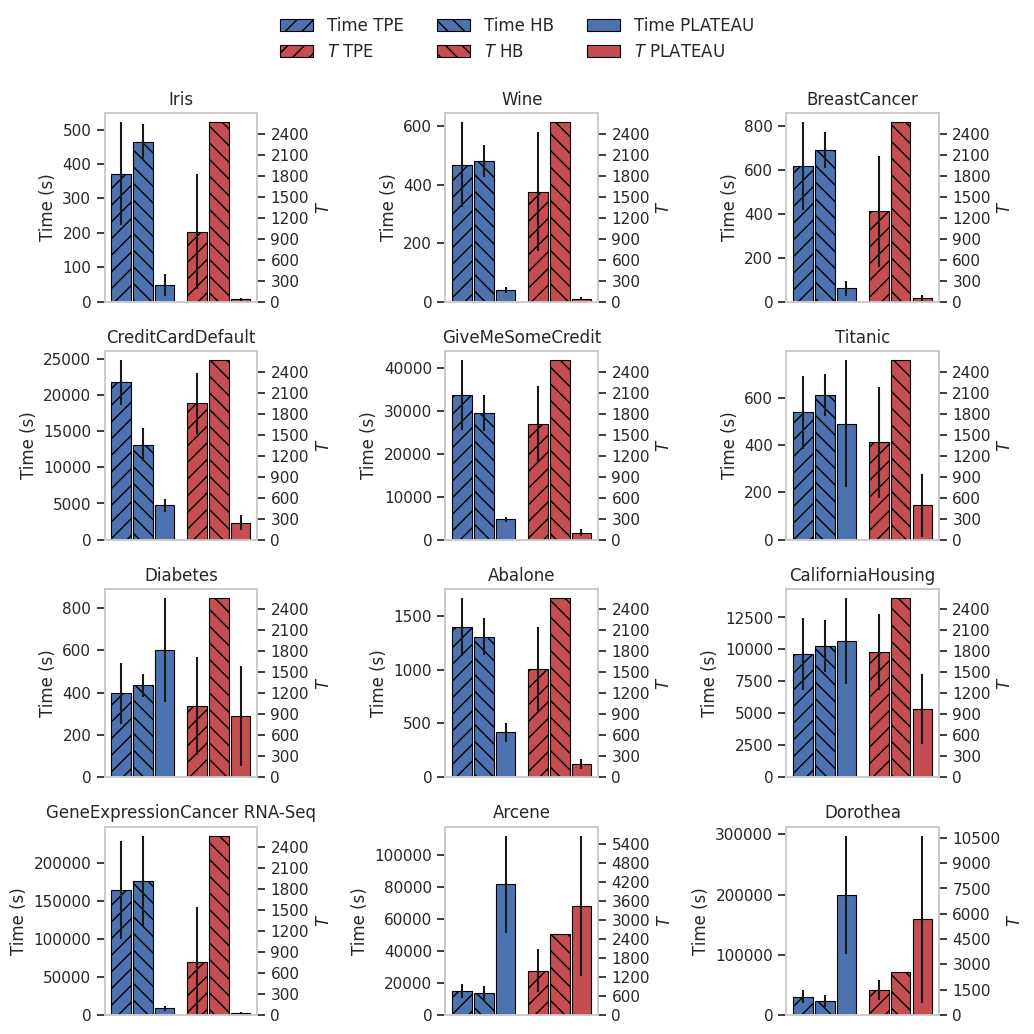

In [12]:
dataset_folders = [
'./iris',
'./wine',
'./breast_cancer',
'./credit_card_default',
'./give_me_some_credit',
'./titanic',
'./diabetes',
'./abalone',
'./california_housing',
'./gene_expression_cancer_rna_seq',
'./arcene',
'./dorothea'
]

datasets_uc = {k.replace(' ', '_'): v for k, v in datasets_nl.items()}
titles = [datasets_uc[s.split('./')[1]] for s in dataset_folders]

deltas = []
for d in dataset_folders:
    deltas.append(DEFAULT_DELTA_GRID[1] if 'titanic' in d or 'gene_expression_cancer_rna_seq' in d else DEFAULT_DELTA_GRID[0])

plot_dataset_comparisons(
    dataset_folders=dataset_folders,
    algorithms = ["TPE", "HB", "PLATEAU"],
    deltas = deltas,
    min_w=3.5,
    min_h=2.3,
    tight_layout_top=0.95,
    ncols=3,
    save_plots=False,
    titles = titles,
)

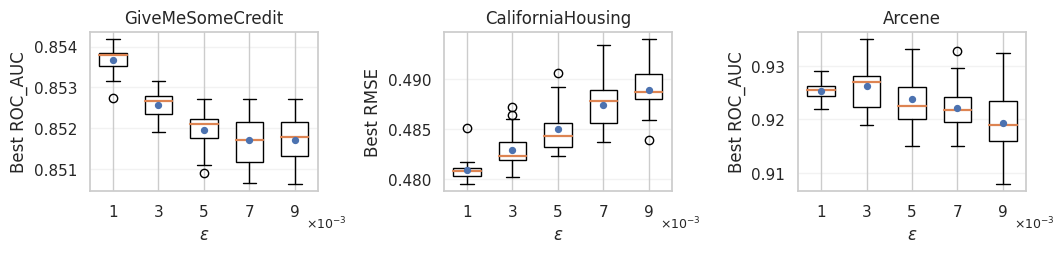

In [13]:
dataset_folders = [
'./give_me_some_credit',    
'./california_housing',
'./arcene',
]

deltas = []
for d in dataset_folders:
    deltas.append(DEFAULT_DELTA_GRID[1:] if 'titanic' in d or 'gene_expression_cancer_rna_seq' in d else DEFAULT_DELTA_GRID[0:])
    
plot_delta_boxplots(
    dataset_folders=dataset_folders,
    deltas_grid = deltas,
    ncols=3,
    min_w=3.6,
    min_h=1.9,
    titles = [datasets_uc[s.split('./')[1]] for s in dataset_folders],
    ylabels= ['Best ROC_AUC', 'Best RMSE', 'Best ROC_AUC']
)